In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron # Used for simple linear classification tasks.
from sklearn.metrics import accuracy_score, classification_report , confusion_matrix

from tensorflow.keras.models import Sequential # Sequential lets you build a neural network layer-by-layer in Keras.

from tensorflow.keras.layers import Dense    #Dense makes the final predictions
from tensorflow.keras.layers import Conv2D # Conv2D extracts features
from tensorflow.keras.layers import Flatten # Flatten reshapes them

from tensorflow.keras.layers import MaxPooling2D  # MaxPooling2D reduces size
from tensorflow.keras.layers import Dropout  # Dropout prevents overfitting

from tensorflow.keras.utils import to_categorical     # converts numeric class labels into one-hot encoded format for training classification models

In [104]:
df = pd.read_csv("sample_data/mnist_train_small.csv", header=None)
df_test = pd.read_csv("sample_data/mnist_test.csv", header=None)
df.columns = ['label'] + [f'pixel_{i}' for i in range(1, 785)]
df_test.columns = ['label'] + [f'pixel_{i}' for i in range(1, 785)]

In [105]:
df.head()

,label,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,pixel_10,pixel_11,pixel_12,pixel_13,pixel_14,pixel_15,pixel_16,pixel_17,pixel_18,pixel_19,pixel_20,pixel_21,pixel_22,pixel_23,pixel_24,pixel_25,pixel_26,pixel_27,pixel_28,pixel_29,pixel_30,pixel_31,pixel_32,pixel_33,pixel_34,pixel_35,pixel_36,pixel_37,pixel_38,pixel_39,...,pixel_745,pixel_746,pixel_747,pixel_748,pixel_749,pixel_750,pixel_751,pixel_752,pixel_753,pixel_754,pixel_755,pixel_756,pixel_757,pixel_758,pixel_759,pixel_760,pixel_761,pixel_762,pixel_763,pixel_764,pixel_765,pixel_766,pixel_767,pixel_768,pixel_769,pixel_770,pixel_771,pixel_772,pixel_773,pixel_774,pixel_775,pixel_776,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783,pixel_784
0,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,15,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [106]:
df.columns

Index(['label', 'pixel_1', 'pixel_2', 'pixel_3', 'pixel_4', 'pixel_5',
       'pixel_6', 'pixel_7', 'pixel_8', 'pixel_9',
       ...
       'pixel_775', 'pixel_776', 'pixel_777', 'pixel_778', 'pixel_779',
       'pixel_780', 'pixel_781', 'pixel_782', 'pixel_783', 'pixel_784'],
      dtype='object', length=785)

In [107]:
df.shape

(20000, 785)

In [108]:
print(df.columns[:10])

Index(['label', 'pixel_1', 'pixel_2', 'pixel_3', 'pixel_4', 'pixel_5',
       'pixel_6', 'pixel_7', 'pixel_8', 'pixel_9'],
      dtype='object')


In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Columns: 785 entries, label to pixel_784
dtypes: int64(785)
memory usage: 119.8 MB


In [110]:
df.isnull().sum()

,0
label,0
pixel_1,0
pixel_2,0
pixel_3,0
pixel_4,0
...,...
pixel_780,0
pixel_781,0
pixel_782,0
pixel_783,0


In [111]:
X_train = df.drop('label', axis=1).values
y_train = df['label'].values
X_test = df_test.drop('label', axis=1).values
y_test = df_test['label'].values

In [112]:
X_train = X_train.astype('float32')/255.0
X_test = X_test.astype('float32')/255.0

In [113]:
X_train_img = X_train.reshape(-1,28,28)
X_test_img = X_test.reshape(-1,28,28)

In [114]:
y_train_cat = to_categorical(y_train,10)
y_test_cat = to_categorical(y_test,10)

In [115]:
Perceptron = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10,activation='softmax')
])

In [116]:
Perceptron.compile(optimizer='sgd',loss='categorial_crossentropy',metrics=['accuracy'])

In [117]:
Perceptron.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])

history_percp = Perceptron.fit(
    X_train_img,
    y_train_cat,
    epochs=5,
    batch_size=32,
    validation_data=(X_test_img, y_test_cat),
    verbose=1
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7354 - loss: 1.1419 - val_accuracy: 0.8476 - val_loss: 0.7133
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8539 - loss: 0.6336 - val_accuracy: 0.8701 - val_loss: 0.5469
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8694 - loss: 0.5275 - val_accuracy: 0.8782 - val_loss: 0.4813
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8796 - loss: 0.4761 - val_accuracy: 0.8867 - val_loss: 0.4438
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8854 - loss: 0.4444 - val_accuracy: 0.8896 - val_loss: 0.4208


In [118]:
acc_percp = Perceptron.evaluate(X_test_img,y_test_cat,verbose=0)[1]
acc_percp

0.8895999789237976

In [119]:
ANN = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(250,activation='relu'),
    Dense(128,activation='relu'),
    Dense(64,activation='relu'),
    Dense(10,activation='softmax'),
])

In [120]:
ANN.compile(optimizer='adam',loss='categorial_crossentropy',metrics=['accuracy'])

In [121]:
ANN.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_ANN = ANN.fit(
    X_train_img,
    y_train_cat,
    epochs=5,
    batch_size=32,
    validation_data=(X_test_img, y_test_cat),
    verbose=1
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9009 - loss: 0.3387 - val_accuracy: 0.9494 - val_loss: 0.1701
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9599 - loss: 0.1370 - val_accuracy: 0.9605 - val_loss: 0.1250
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9700 - loss: 0.0911 - val_accuracy: 0.9616 - val_loss: 0.1330
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9783 - loss: 0.0679 - val_accuracy: 0.9652 - val_loss: 0.1238
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9854 - loss: 0.0466 - val_accuracy: 0.9673 - val_loss: 0.1236


In [122]:
acc_ANN = ANN.evaluate(X_test_img,y_test_cat,verbose=0)[1]
acc_ANN

0.9672999978065491

In [123]:
X_train_img = X_train.reshape(-1,28,28,1)
X_test_img = X_test.reshape(-1,28,28,1)

In [124]:
CNN = Sequential([
    Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64,kernel_size=(3,3),activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(10,activation='softmax')
])

In [125]:
CNN.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [126]:
history_CNN = CNN.fit(X_train_img,y_train_cat,epochs=5,batch_size=32,validation_data=(X_test_img,y_test_cat),verbose=1)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - accuracy: 0.8687 - loss: 0.4190 - val_accuracy: 0.9713 - val_loss: 0.0983
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.9584 - loss: 0.1403 - val_accuracy: 0.9820 - val_loss: 0.0613
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.9710 - loss: 0.0951 - val_accuracy: 0.9817 - val_loss: 0.0524
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.9758 - loss: 0.0750 - val_accuracy: 0.9796 - val_loss: 0.0645
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.9810 - loss: 0.0620 - val_accuracy: 0.9863 - val_loss: 0.0442


In [127]:
acc_CNN = CNN.evaluate(X_test_img,y_test_cat,verbose=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9863 - loss: 0.0442


In [128]:
def plot_training(history, title):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'],label='Train')
    plt.plot(history.history['val_accuracy'],label='Val')
    plt.title(f'{title} Accuracy')
    plt.legend()
    plt.show()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'],label='Train')
    plt.plot(history.history['val_loss'],label='Val')
    plt.title(f'{title} Loss')
    plt.legend()
    plt.show()

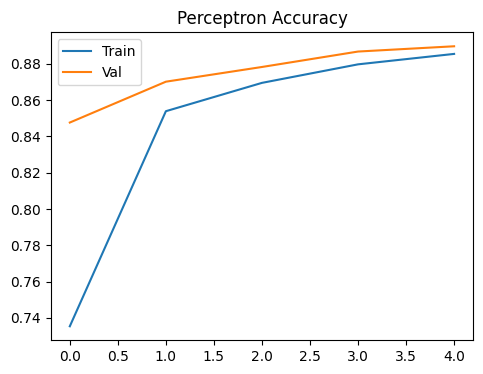

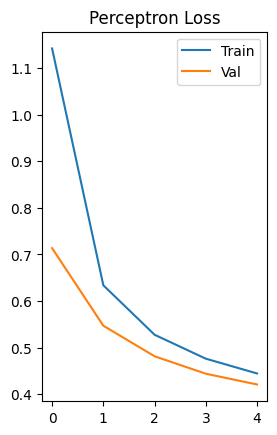

In [129]:
plot_training(history_percp,"Perceptron")

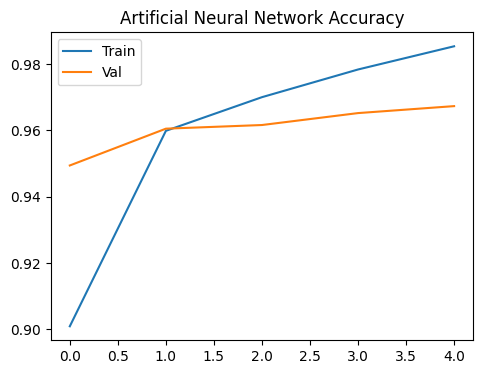

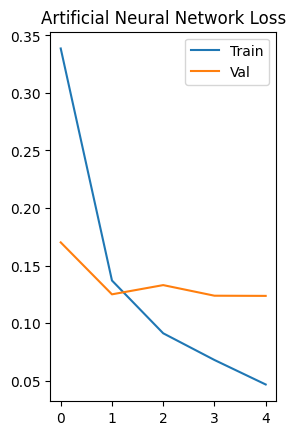

In [130]:
plot_training(history_ANN,"Artificial Neural Network")

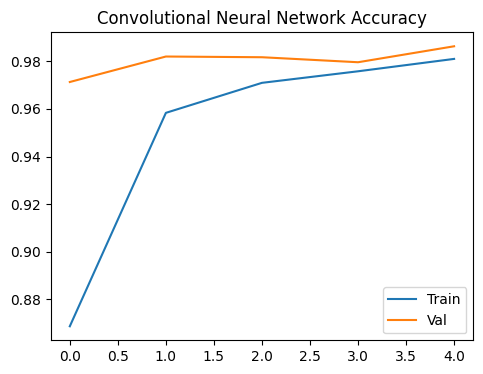

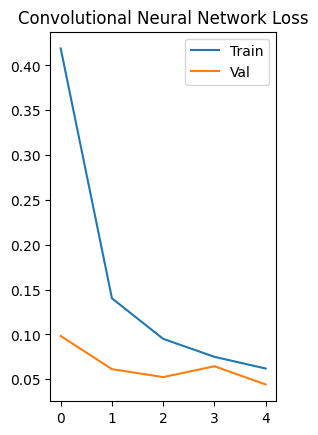

In [131]:
plot_training(history_CNN,"Convolutional Neural Network")

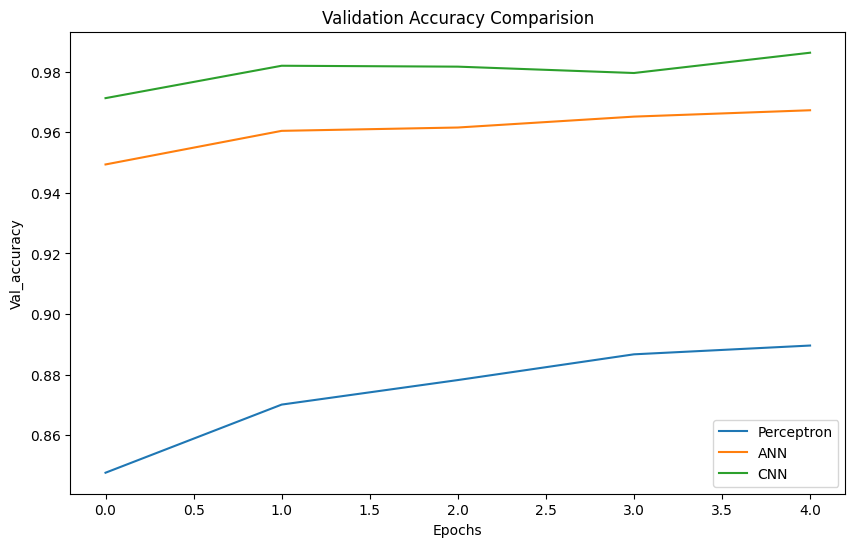

In [132]:
plt.figure(figsize=(10,6))
plt.plot(history_percp.history['val_accuracy'],label='Perceptron')
plt.plot(history_ANN.history['val_accuracy'],label='ANN')
plt.plot(history_CNN.history['val_accuracy'],label='CNN')
plt.title('Validation Accuracy Comparision')
plt.xlabel('Epochs')
plt.ylabel('Val_accuracy')
plt.legend()
plt.show()

--- Side-by-Side Accuracy Comparison ---


,Model,Test Accuracy
0,Perceptron,88.96%
1,Artificial Neural Network (ANN),96.73%
2,Convolutional Neural Network (CNN),98.63%


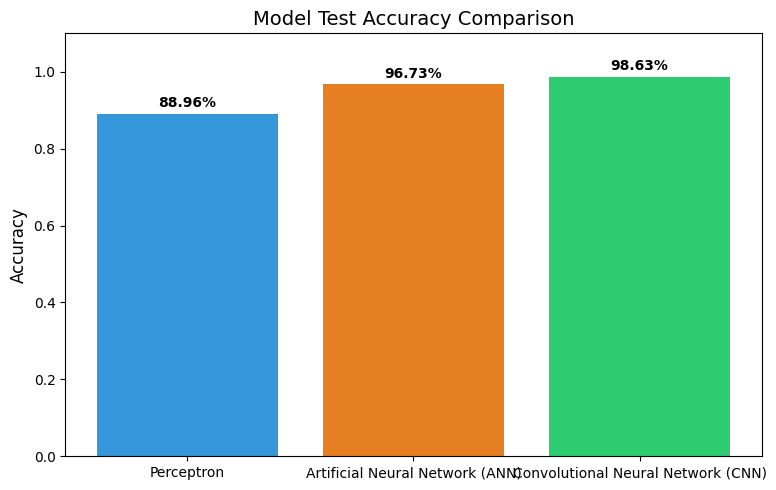

In [133]:
def compare_models(acc_percp, acc_ANN, acc_CNN):
    # Extract final accuracies
    # acc_CNN is a list [loss, accuracy], so we extract the element at index 1
    cnn_accuracy = acc_CNN[1] if isinstance(acc_CNN, list) else acc_CNN

    # Create comparison dictionary
    comparison_data = {
        'Model': ['Perceptron', 'Artificial Neural Network (ANN)', 'Convolutional Neural Network (CNN)'],
        'Test Accuracy': [acc_percp, acc_ANN, cnn_accuracy]
    }

    # Display as DataFrame
    comparison_df = pd.DataFrame(comparison_data)
    print("--- Side-by-Side Accuracy Comparison ---")
    display(comparison_df.style.format({'Test Accuracy': '{:.2%}'}))

    # Plot side-by-side comparison
    plt.figure(figsize=(8, 5))
    bars = plt.bar(comparison_df['Model'], comparison_df['Test Accuracy'], color=['#3498db', '#e67e22', '#2ecc71'])
    plt.title('Model Test Accuracy Comparison', fontsize=14)
    plt.ylabel('Accuracy', fontsize=12)
    plt.ylim(0, 1.1)

    # Add values on top of the bars
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.2%}", ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()

# Call the function with our models' accuracies
compare_models(acc_percp, acc_ANN, acc_CNN)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


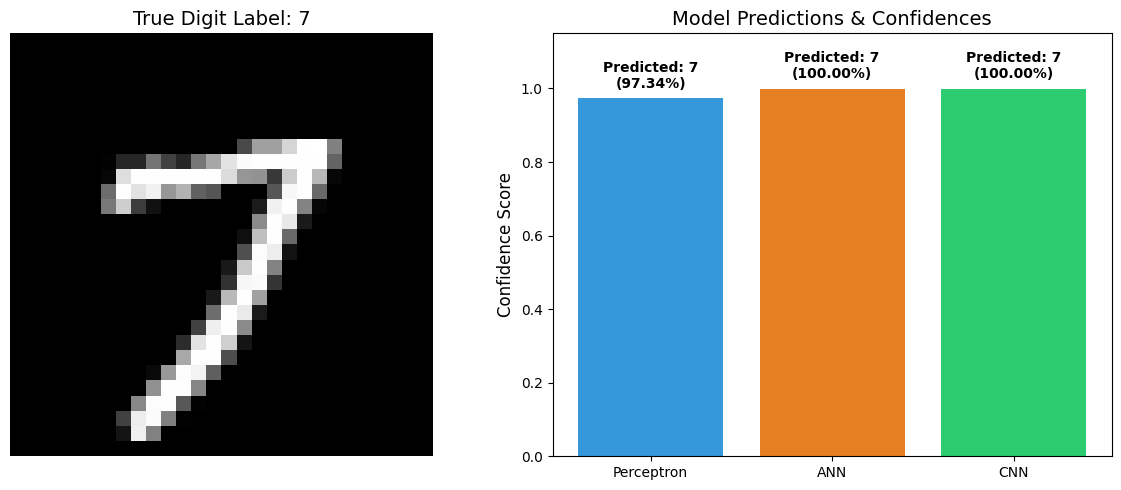

In [134]:
def compare_predictions_on_image(image_index=None):
    # Select a random test image if index is not provided
    if image_index is None:
        image_index = np.random.randint(0, len(X_test_img))

    # Get the image data
    img_flat = X_test[image_index].reshape(1, 28, 28) # flattened or 2D image for Perceptron/ANN
    img_cnn = X_test_img[image_index:image_index+1] # 4D shape (1, 28, 28, 1) for CNN
    true_label = y_test[image_index]

    # Make predictions
    pred_percp = Perceptron.predict(img_flat)[0]
    pred_ann = ANN.predict(img_flat, verbose=0)[0]
    pred_cnn = CNN.predict(img_cnn, verbose=0)[0]

    # Get predicted classes
    class_percp = np.argmax(pred_percp)
    class_ann = np.argmax(pred_ann)
    class_cnn = np.argmax(pred_cnn)

    # Get confidences
    conf_percp = pred_percp[class_percp]
    conf_ann = pred_ann[class_ann]
    conf_cnn = pred_cnn[class_cnn]

    # Plot the image and comparison
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Plot the input image
    axes[0].imshow(X_test_img[image_index].reshape(28, 28), cmap='gray')
    axes[0].set_title(f"True Digit Label: {true_label}", fontsize=14)
    axes[0].axis('off')

    # Plot side-by-side predictions
    models = ['Perceptron', 'ANN', 'CNN']
    predicted_classes = [class_percp, class_ann, class_cnn]
    confidences = [conf_percp, conf_ann, conf_cnn]

    bars = axes[1].bar(models, confidences, color=['#3498db', '#e67e22', '#2ecc71'])
    axes[1].set_title("Model Predictions & Confidences", fontsize=14)
    axes[1].set_ylabel("Confidence Score", fontsize=12)
    axes[1].set_ylim(0, 1.15)

    # Label the predicted digit and confidence on top of each bar
    for bar, pred_class, conf in zip(bars, predicted_classes, confidences):
        height = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width()/2,
            height + 0.02,
            f"Predicted: {pred_class}\n({conf:.2%})",
            ha='center',
            va='bottom',
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()

# Run prediction comparison on a random test image
compare_predictions_on_image()


=== Example 1 (Test Image Index: 9953) ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


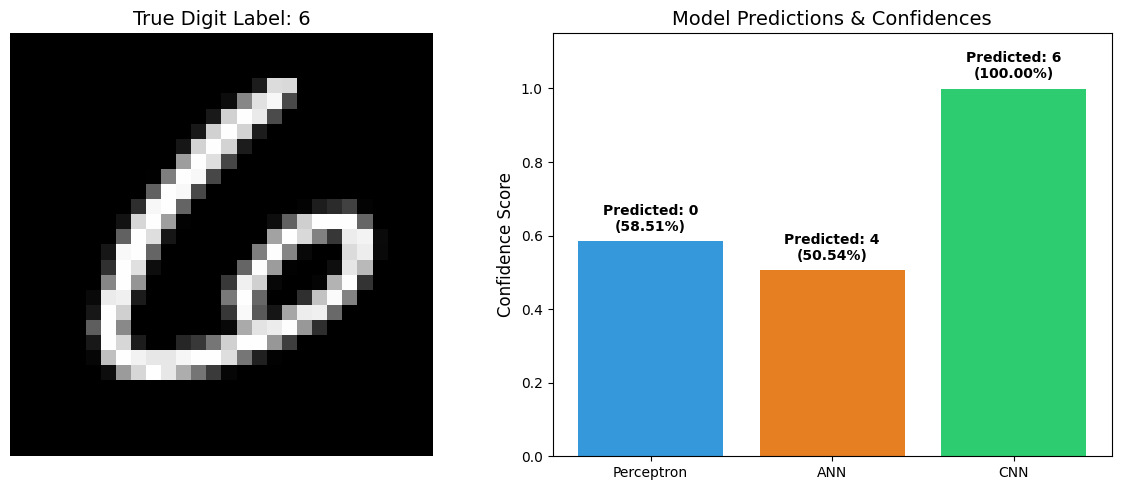


=== Example 2 (Test Image Index: 3850) ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


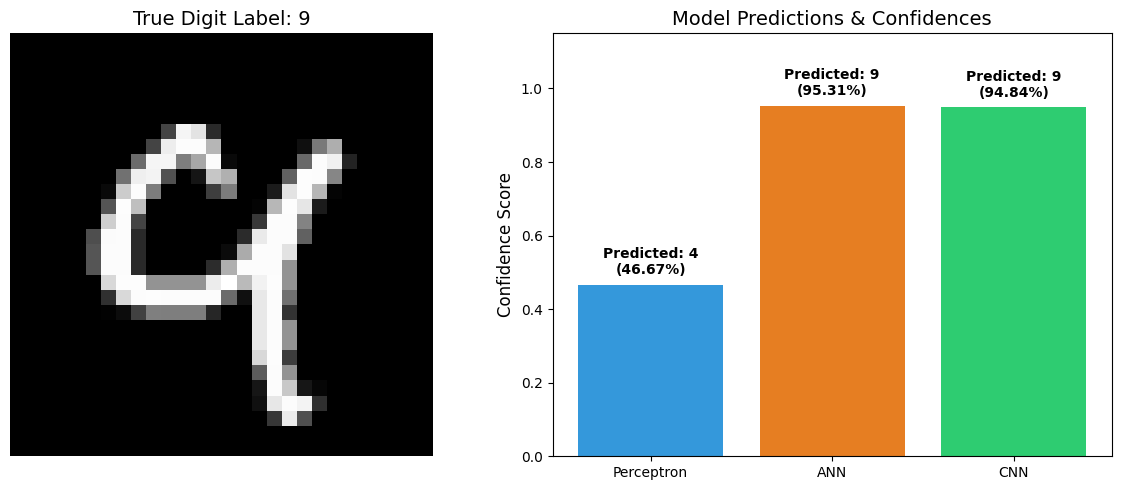


=== Example 3 (Test Image Index: 4962) ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


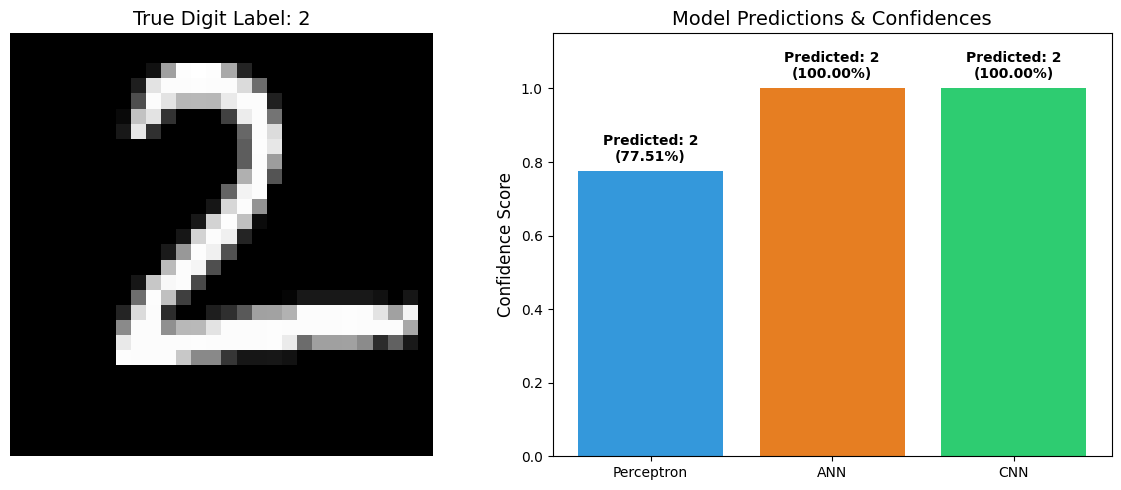


=== Example 4 (Test Image Index: 3886) ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


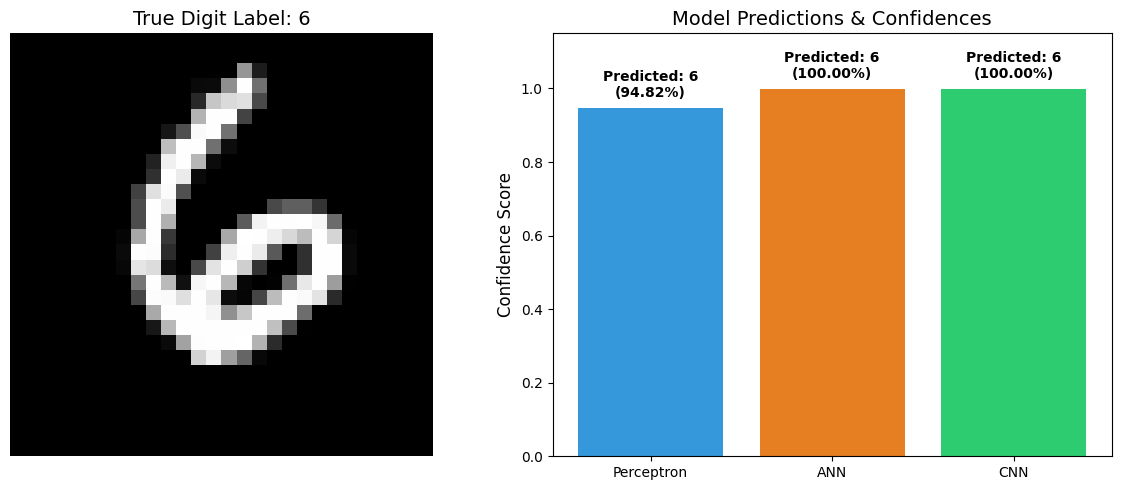

In [135]:
# Select 4 unique random indices from the test dataset
np.random.seed(1)  # Set seed for reproducible examples
random_indices = np.random.choice(len(X_test_img), size=4, replace=False)

# Loop through and compare predictions for each selected image
for i, idx in enumerate(random_indices, start=1):
    print(f"\n=== Example {i} (Test Image Index: {idx}) ===")
    compare_predictions_on_image(image_index=idx)

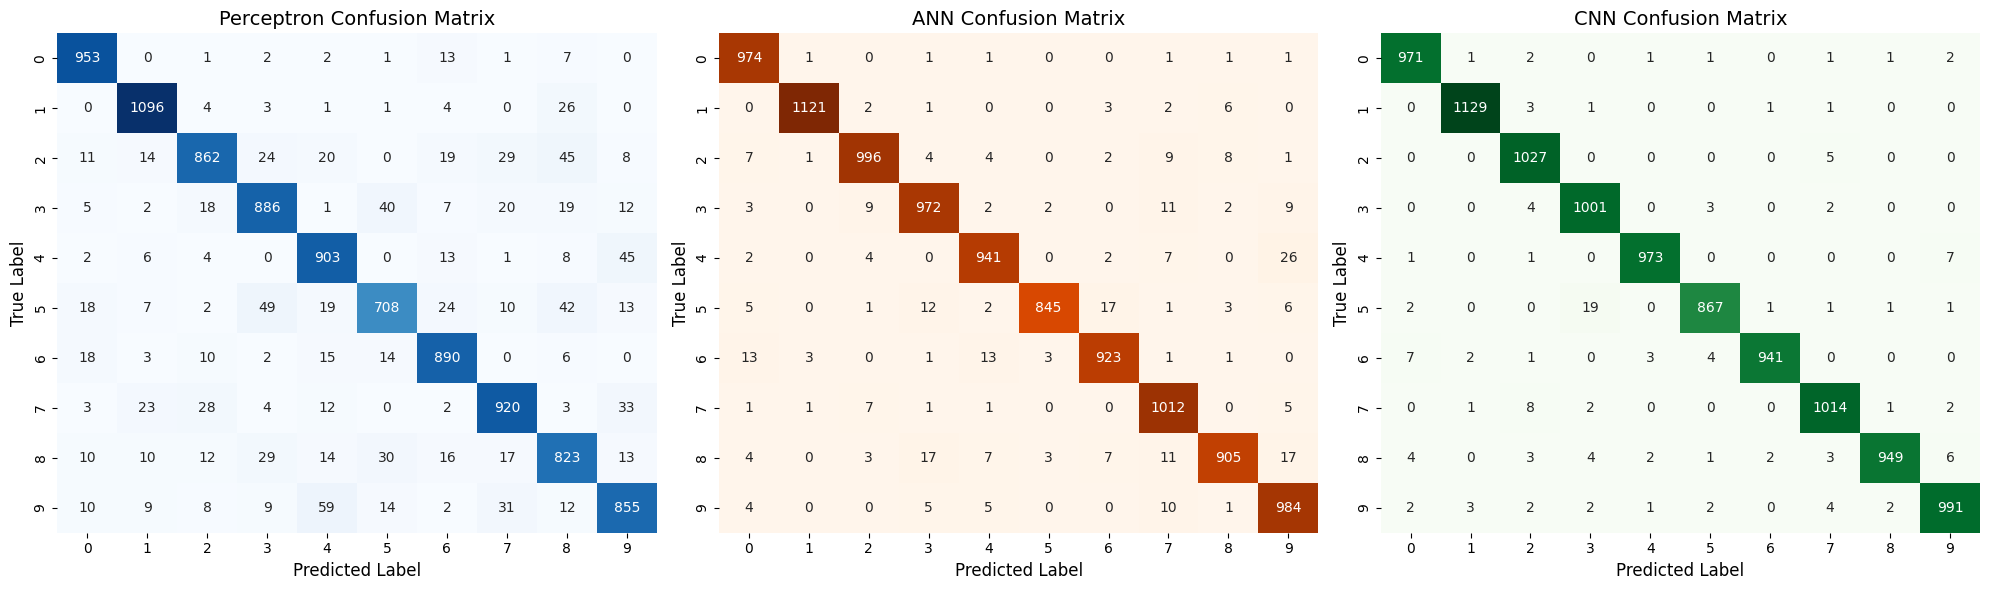

In [136]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Get predictions from all models on the entire test dataset
# Perceptron and ANN expect flattened images of shape (-1, 28, 28) but we passed X_test_img which is (-1, 28, 28, 1).
# We'll reshape accordingly to make sure each model gets its correct input format.
X_test_flat_3d = X_test_img.reshape(-1, 28, 28)

y_pred_percp = np.argmax(Perceptron.predict(X_test_flat_3d, verbose=0), axis=1)
y_pred_ann = np.argmax(ANN.predict(X_test_flat_3d, verbose=0), axis=1)
y_pred_cnn = np.argmax(CNN.predict(X_test_img, verbose=0), axis=1)

# 2. Compute Confusion Matrices
cm_percp = confusion_matrix(y_test, y_pred_percp)
cm_ann = confusion_matrix(y_test, y_pred_ann)
cm_cnn = confusion_matrix(y_test, y_pred_cnn)

# 3. Plot Confusion Matrices side-by-side as heatmaps
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Perceptron Heatmap
sns.heatmap(cm_percp, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Perceptron Confusion Matrix', fontsize=14)
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)

# ANN Heatmap
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Oranges', ax=axes[1], cbar=False)
axes[1].set_title('ANN Confusion Matrix', fontsize=14)
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_ylabel('True Label', fontsize=12)

# CNN Heatmap
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Greens', ax=axes[2], cbar=False)
axes[2].set_title('CNN Confusion Matrix', fontsize=14)
axes[2].set_xlabel('Predicted Label', fontsize=12)
axes[2].set_ylabel('True Label', fontsize=12)

plt.tight_layout()
plt.show()